In [1]:
%pip install split-folders
%pip install patchify
%pip install tifffile imagecodecs
%pip install tensorflow
%pip install segmentation-models
%pip install opencv-python
%pip install matplotlib
%pip install imutils

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install keras

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Стандартные библиотеки
import os
import glob
import random

# Настройки и инициализации
%env SM_FRAMEWORK=tf.keras

# Сторонние библиотеки
import cv2
import numpy as np # [[6]] [[10]]
from matplotlib import pyplot as plt
from patchify import patchify
from PIL import Image # [[10]]
import segmentation_models as sm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import MeanIoU
import tifffile as tiff

# Инициализация объекта scaler
scaler = MinMaxScaler()

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.


In [3]:
import tensorflow as tf; 
print(tf.config.list_physical_devices('GPU'))

[]


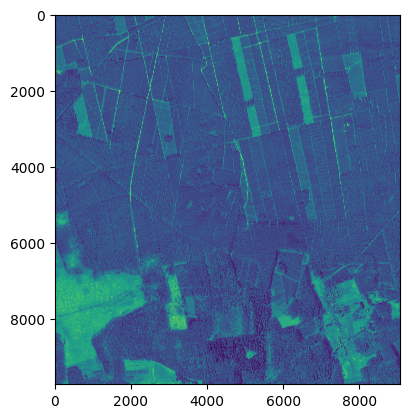

In [4]:
temp_img = tiff.imread('images/M-33-7-A-d-2-3.tif')
plt.imshow(temp_img[:,:,0])

(9711, 9081, 3)
uint8
(9711, 9081)
Labels are:  [0 1 2 4]  and the counts are:  [10649007    60415 75869435  1606734]


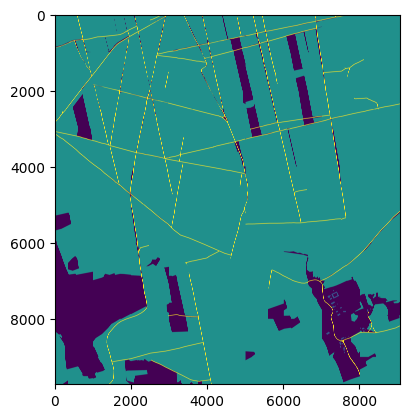

In [5]:
temp_mask = tiff.imread('masks/M-33-7-A-d-2-3.tif')
plt.imshow(temp_mask)

print(temp_img.shape)
print(temp_img.dtype)
print(temp_mask.shape)

labels, count = np.unique(temp_mask, return_counts=True) #Check for each channel. All chanels are identical
print("Labels are: ", labels, " and the counts are: ", count)

In [6]:
patch_size = 256

## 1.2. Обрезка исходных растров на фрагменты (патчи) размером 256x256. Сохраните их в каталог на локальное хранилице

In [7]:
from pathlib import Path
#Считываем изображения из подкаталога 'images'.
#Поскольку все изображения имеют разный размер, у нас есть 2 варианта: изменить размер или обрезать.
#Но некоторые изображения слишком большие, а некоторые маленькие. Изменение размера изменит размер реальных объектов.
#Поэтому мы обрезаем их до ближайшего размера, кратного 256, а затем
#разделим все изображения на участки размером 256x256x3.
img_dir="images/"

# Создадим директорию для хранения батчей
Path('256_patches/images/').mkdir(parents=True, exist_ok=True)

for path, subdirs, files in os.walk(img_dir):
    print(path)
    dirname = path.split(os.path.sep)[-1]
    print(dirname)
    images = os.listdir(path)
    print(images)
    for i, image_name in enumerate(images):
        if image_name.endswith(".tif"):

            image = tiff.imread(path + "/" + image_name)

            SIZE_X = (image.shape[1] // patch_size) * patch_size
            SIZE_Y = (image.shape[0] // patch_size) * patch_size

            image = image[0:SIZE_Y, 0:SIZE_X]

            print("Now patchifying image:", path + "/" + image_name)
            patches_img = patchify(image, (256, 256, 3), step=256)

            for i in range(patches_img.shape[0]):
                for j in range(patches_img.shape[1]):

                    single_patch_img = patches_img[i,j,:,:]
                    single_patch_img = single_patch_img[0]

                    tiff.imwrite("256_patches/images/" + image_name +
                                 "patch_" + str(i) + str(j) + ".tif", single_patch_img, photometric='rgb')

images/
images/
['M-33-20-D-c-4-2.tif', 'M-33-20-D-d-3-3.tif', 'M-33-32-B-b-4-4.tif', 'M-33-48-A-c-4-4.tif', 'M-33-7-A-d-2-3.tif', 'M-33-7-A-d-3-2.tif', 'M-34-32-B-a-4-3.tif', 'M-34-32-B-b-1-3.tif', 'M-34-5-D-d-4-2.tif', 'M-34-51-C-b-2-1.tif', 'M-34-51-C-d-4-1.tif', 'M-34-55-B-b-4-1.tif', 'M-34-56-A-b-1-4.tif', 'M-34-6-A-d-2-2.tif', 'M-34-65-D-a-4-4.tif', 'M-34-65-D-c-4-2.tif', 'M-34-65-D-d-4-1.tif', 'M-34-68-B-a-1-3.tif', 'M-34-77-B-c-2-3.tif', 'N-33-104-A-c-1-1.tif', 'N-33-119-C-c-3-3.tif', 'N-33-130-A-d-3-3.tif', 'N-33-130-A-d-4-4.tif', 'N-33-139-C-d-2-2.tif', 'N-33-139-C-d-2-4.tif', 'N-33-139-D-c-1-3.tif', 'N-33-60-D-c-4-2.tif', 'N-33-60-D-d-1-2.tif', 'N-33-96-D-d-1-1.tif', 'N-34-106-A-b-3-4.tif', 'N-34-106-A-c-1-3.tif', 'N-34-140-A-b-3-2.tif', 'N-34-140-A-b-4-2.tif', 'N-34-140-A-d-3-4.tif', 'N-34-140-A-d-4-2.tif', 'N-34-61-B-a-1-1.tif', 'N-34-66-C-c-4-3.tif', 'N-34-77-A-b-1-4.tif', 'N-34-94-A-b-2-4.tif', 'N-34-97-C-b-1-2.tif', 'N-34-97-D-c-2-4.tif']
Now patchifying image: images//

In [8]:
mask_dir="masks/"

# Создадим директорию для хранения батчей
Path('256_patches/masks/').mkdir(parents=True, exist_ok=True)

for path, subdirs, files in os.walk(mask_dir):
    print(path)
    dirname = path.split(os.path.sep)[-1]

    masks = os.listdir(path)
    for i, mask_name in enumerate(masks):
        if mask_name.endswith(".tif"):

            mask = cv2.imread(path + "/" + mask_name)

            SIZE_X = (mask.shape[1] // patch_size) * patch_size
            SIZE_Y = (mask.shape[0] // patch_size) * patch_size

            mask = mask[0:SIZE_Y, 0:SIZE_X]

            print("Now patchifying mask:", path + "/" + mask_name)
            patches_mask = patchify(mask, (256, 256, 1), step=256)

            for i in range(patches_mask.shape[0]):
                for j in range(patches_mask.shape[1]):

                    single_patch_mask = patches_mask[i,j,:,:]
                    single_patch_mask = single_patch_mask[0]
                    tiff.imwrite("256_patches/masks/" +
                               mask_name + "patch_" + str(i) + str(j) + ".tif", single_patch_mask, photometric='minisblack')

masks/
Now patchifying mask: masks//M-33-20-D-c-4-2.tif
Now patchifying mask: masks//M-33-20-D-d-3-3.tif
Now patchifying mask: masks//M-33-32-B-b-4-4.tif
Now patchifying mask: masks//M-33-48-A-c-4-4.tif
Now patchifying mask: masks//M-33-7-A-d-2-3.tif
Now patchifying mask: masks//M-33-7-A-d-3-2.tif
Now patchifying mask: masks//M-34-32-B-a-4-3.tif
Now patchifying mask: masks//M-34-32-B-b-1-3.tif
Now patchifying mask: masks//M-34-5-D-d-4-2.tif
Now patchifying mask: masks//M-34-51-C-b-2-1.tif
Now patchifying mask: masks//M-34-51-C-d-4-1.tif
Now patchifying mask: masks//M-34-55-B-b-4-1.tif
Now patchifying mask: masks//M-34-56-A-b-1-4.tif
Now patchifying mask: masks//M-34-6-A-d-2-2.tif
Now patchifying mask: masks//M-34-65-D-a-4-4.tif
Now patchifying mask: masks//M-34-65-D-c-4-2.tif
Now patchifying mask: masks//M-34-65-D-d-4-1.tif
Now patchifying mask: masks//M-34-68-B-a-1-3.tif
Now patchifying mask: masks//M-34-77-B-c-2-3.tif
Now patchifying mask: masks//N-33-104-A-c-1-1.tif
Now patchifying 

In [9]:
from imutils.paths import list_images
img_dir = '256_patches/images/'
mask_dir = '256_patches/masks/'


img_list = sorted(os.listdir(img_dir))
msk_list = sorted(os.listdir(mask_dir))

num_images = len(os.listdir(img_dir))

print(f'Image patches count: {len(img_list)}')
print(f'Masks patches count: {len(msk_list)}')

Image patches count: 41646
Masks patches count: 41646


<Figure size 1200x800 with 0 Axes>

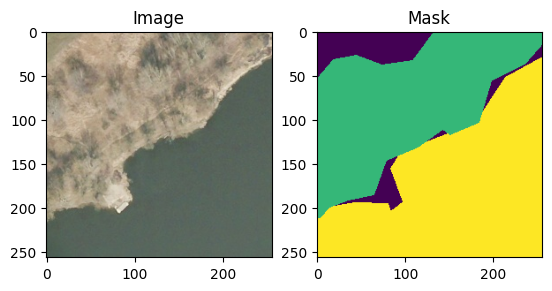

In [10]:
img_num = random.randint(0, num_images - 1)

img_for_plot = tiff.imread(os.path.join(img_dir, img_list[img_num]))
mask_for_plot = tiff.imread(os.path.join(mask_dir, msk_list[img_num]))

fig = plt.figure(figsize=(12,8), dpi= 100, facecolor='w', edgecolor='k')
figure, axis = plt.subplots(1, 2)

axis[0].imshow(img_for_plot, vmin=0,vmax=10)
axis[0].set_title('Image')

axis[1].imshow(mask_for_plot)
axis[1].set_title('Mask')

plt.show()

In [15]:
img_directory = '256_patches/images/'
msk_directory = '256_patches/masks/'

# Получаем список путей к изображениям и маскам
img_list = glob.glob(img_directory + '*.tif')
msk_list = glob.glob(msk_directory + '*.tif')

Path('256_patches/data/images/').mkdir(parents=True, exist_ok=True)
Path('256_patches/data/masks/').mkdir(parents=True, exist_ok=True)

useless=0
for i in range(len(img_list)):
    img_name  = img_list[i].split('/')[-1]
    
    mask_name = msk_list[i].split('/')[-1]

    img_name = Path(img_list[i]).name
    mask_name = Path(msk_list[i]).name

    #temp_mask=temp_mask.astype(np.uint8)

    val, counts = np.unique(temp_mask, return_counts=True)

    if (1 - (counts[0]/counts.sum())) > 0.05:  # От 5% полезной площади
        tiff.imwrite('256_patches/data/images/' + img_name, temp_image, photometric='rgb')
        tiff.imwrite('256_patches/data/masks/' + mask_name, temp_mask, photometric='minisblack')

    else:
        useless += 1

print("Total useful images are: ", len(img_list) - useless)
print("Total useless images are: ", useless)

Total useful images are:  41646
Total useless images are:  0


In [16]:
input_folder = '256_patches/data/'
output_folder = '256_patches/splitted_data/'
Path(output_folder).mkdir(parents=True, exist_ok=True)

In [17]:
# Разделение данных на обучающую и проверочную выборки
import shutil
import splitfolders
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.75, .25), group_prefix=None)

In [22]:
import shutil

src_train_img = '256_patches/splitted_data/train/images/'
src_train_msk = '256_patches/splitted_data/train/masks/'
src_val_img   = '256_patches/splitted_data/val/images/'
src_val_msk   = '256_patches/splitted_data/val/masks/'

dst_train_img = 'dataset/train_image/train/'
dst_train_msk = 'dataset/train_mask/train/'
dst_val_img   = 'dataset/val_image/val/'
dst_val_msk   = 'dataset/val_mask/val/'

shutil.copytree(src_train_img, dst_train_img)
shutil.copytree(src_train_msk, dst_train_msk)
shutil.copytree(src_val_img, dst_val_img)
shutil.copytree(src_val_msk, dst_val_msk)

'dataset/val_mask/val/'

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from imutils.paths import list_images

In [24]:
train_img_dir = 'dataset/train_image/'
train_msk_dir = 'dataset/train_mask/'
val_img_dir   = 'dataset/val_image/'
val_msk_dir   = 'dataset/val_mask/'

img_paths = sorted(list_images(train_img_dir))
msk_paths = sorted(list_images(train_msk_dir))

<Figure size 1200x800 with 0 Axes>

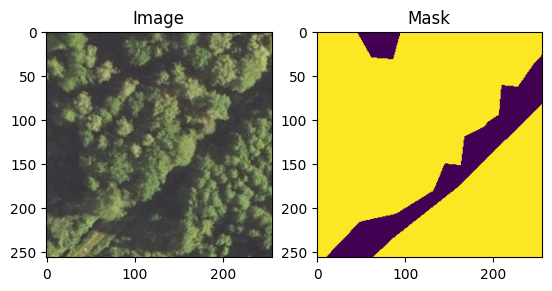

In [25]:
import random
img_count = len(os.listdir(train_img_dir))
img_num = random.randint(0, img_count - 1)

img_for_plot = cv2.cvtColor(
    cv2.imread(img_paths[img_num]),
    cv2.COLOR_BGR2RGB
)

mask_for_plot = tiff.imread(msk_paths[img_num])

fig=plt.figure(figsize=(12,8), dpi= 100, facecolor='w', edgecolor='k')

figure, axis = plt.subplots(1, 2)

axis[0].imshow(img_for_plot, cmap=plt.get_cmap('gray'), vmin=0, vmax=100)
axis[0].set_title('Image')

axis[1].imshow(mask_for_plot)
axis[1].set_title('Mask')

plt.show()

## 2.2. Предобработка обучающей выборки

In [26]:
scaler = MinMaxScaler()

BACKBONE = 'resnet34'
num_class = 5
preprocess_input = sm.get_preprocessing(BACKBONE)

In [27]:
from tensorflow.keras.utils import to_categorical
def preprocess_data(img, mask, num_class):
    img = scaler.fit_transform(img.reshape(-1, img.shape[-1])).reshape(img.shape)
    img = preprocess_input(img)
    mask = mask[:,:,:,0]
    mask = to_categorical(mask, num_class)

    return (img, mask)

In [28]:
seed=24
batch_size= 30
num_class=5

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
def trainGenerator(train_images_path, train_masks_path, num_class):
    img_data_gen_args = dict(horizontal_flip=True,
                      vertical_flip=True)

    image_datagen = ImageDataGenerator(**img_data_gen_args)
    image_generator = image_datagen.flow_from_directory(
        train_images_path,
        class_mode = None,
        batch_size = batch_size,
        seed = seed)

    target_datagen = ImageDataGenerator(**img_data_gen_args)
    target_generator = target_datagen.flow_from_directory(
        train_masks_path,
        class_mode = None,
        batch_size = batch_size,
        seed = seed)

    train_generator = zip(image_generator, target_generator)

    for (img, target) in train_generator:
        processed_img, processed_target = preprocess_data(img, target, num_class)
        yield (processed_img, processed_target)

In [30]:
train_img_gen = trainGenerator(train_img_dir, train_msk_dir, num_class)
val_img_gen = trainGenerator(val_img_dir, val_msk_dir, num_class)

train_steps_count = len(list(list_images(train_img_dir))) // batch_size
val_steps_count = len(list(list_images(val_img_dir))) // batch_size
print(f'Train steps per epoch: {train_steps_count}')
print(f'Val steps per epoch: {val_steps_count}')

Train steps per epoch: 1041
Val steps per epoch: 347


In [31]:
def count_files_in_folder(folder_path):
    return len(os.listdir(folder_path))

print("\nКоличество файлов в каждой папке:")
print("Train images count:", count_files_in_folder(train_img_dir))
print("Train masks count:", count_files_in_folder(train_msk_dir))
print("Val images count:", count_files_in_folder(val_img_dir))
print("Val masks count:", count_files_in_folder(val_msk_dir))


Количество файлов в каждой папке:
Train images count: 1
Train masks count: 1
Val images count: 1
Val masks count: 1


In [32]:
train_img_batch, train_mask_batch = next(train_img_gen)
train_mask_batch_argmax = np.argmax(train_mask_batch, axis=3)

val_img_batch, val_mask_batch = next(val_img_gen)
val_mask_batch_argmax = np.argmax(val_mask_batch, axis=3)

print(f'Train image shape: {train_img_batch.shape}')
print(f'Train mask shape: {train_mask_batch.shape}')
print(f'Val image shape: {val_img_batch.shape}')
print(f'Val mask shape: {val_mask_batch.shape}')

Found 31234 images belonging to 1 classes.
Found 31234 images belonging to 1 classes.
Found 10412 images belonging to 1 classes.
Found 10412 images belonging to 1 classes.
Train image shape: (30, 256, 256, 3)
Train mask shape: (30, 256, 256, 5)
Val image shape: (30, 256, 256, 3)
Val mask shape: (30, 256, 256, 5)


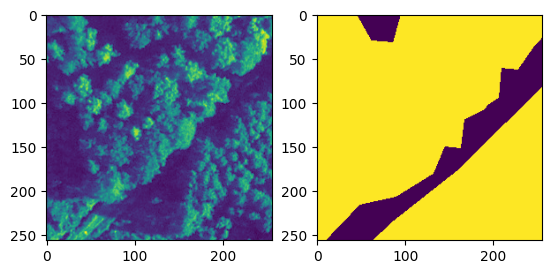

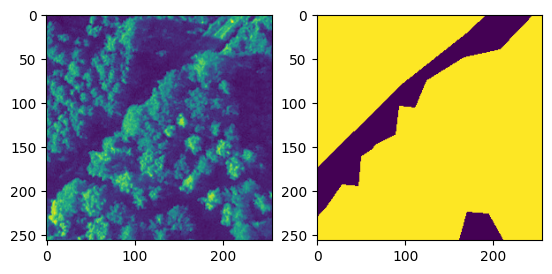

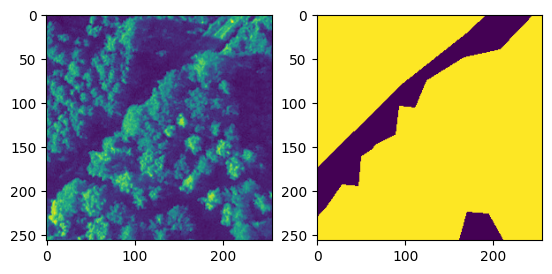

In [33]:
x, y = train_img_gen.__next__()

for i in range(0,3):
    image = x[i][:,:,0]
    mask = np.argmax(y[i], axis=2)
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.subplot(1,2,2)
    plt.imshow(mask)
    plt.show()
    labels, count = np.unique(mask, return_counts=True)

# Этап 3. Разработка архитектуры модели. Обучение модели

In [34]:
num_train_imgs = len(os.listdir('dataset/train_image/train'))

# Получаем количество шагов на эпоху, разделив количество изображений для обучения на размер пакета
steps_per_epoch = num_train_imgs//batch_size

# Получаем высоту изображения
IMG_HEIGHT = x.shape[1]

# Получаем ширину изображения
IMG_WIDTH  = x.shape[2]

# Получаем количество каналов изображения
IMG_CHANNELS = x.shape[3]

# Задаем количество классов
n_classes=5

print(num_train_imgs, steps_per_epoch, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

31234 1041 256 256 3


In [35]:
import tensorflow.keras.backend as K

# Функция для вычисления коэффициента Жаккара
def jacard_coef(y_true, y_pred):
    # Преобразование меток в одномерные массивы
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Приведение типов
    y_true_f = K.cast(y_true_f, 'float32')
    y_pred_f = K.cast(y_pred_f, 'float32')

    # Вычисление пересечения
    intersection = K.sum(y_true_f * y_pred_f)

    # Коэффициент Жаккара
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)


# Список метрик для оценки модели
metrics=['accuracy', jacard_coef]

In [36]:
x, y = next(train_img_gen)
print(f'Размеры данных: {x.shape}')
print(f'Размеры меток: {y.shape}')

Размеры данных: (30, 256, 256, 3)
Размеры меток: (30, 256, 256, 5)


In [37]:
n_classes=5

BACKBONE = 'resnet34'

model_resnet_backbone = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation='softmax')

model_resnet_backbone.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)

model_resnet_backbone.summary()

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, None,      │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, None,      │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, None,      │      9,408 │ zero_padding2d[0… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, None,      │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, None,      │          0 │ bn0[0][0]         │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, None,      │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, None,      │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, None,      │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, None,      │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, None,      │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, None,      │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, None,      │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, None,      │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, None,      │      4,096 │ stage1_unit1_rel

 Total params: 24,456,734 (93.30 MB)

 Trainable params: 24,439,384 (93.23 MB)

 Non-trainable params: 17,350 (67.77 KB)

In [38]:
history=model_resnet_backbone.fit(
          train_img_gen,
          steps_per_epoch=steps_per_epoch,
          epochs=5,
          verbose=1,
          validation_data=None)

Epoch 1/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5900s 6s/step - accuracy: 0.9736 - jacard_coef: 0.9086 - loss: 0.1002
Epoch 2/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5763s 6s/step - accuracy: 1.0000 - jacard_coef: 0.9994 - loss: 2.8812e-04
Epoch 3/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5728s 6s/step - accuracy: 1.0000 - jacard_coef: 0.9999 - loss: 7.1071e-05
Epoch 4/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5683s 5s/step - accuracy: 0.9920 - jacard_coef: 0.9776 - loss: 0.0346
Epoch 5/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5708s 5s/step - accuracy: 0.9997 - jacard_coef: 0.9986 - loss: 0.0010


In [39]:
model_resnet_backbone.save('model_resnet.keras')

## Этап 4. Визуализация процесса обучения. Оценка точности

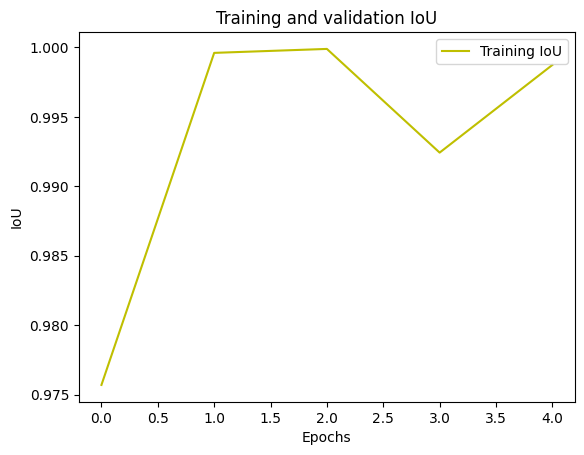

In [40]:
acc = history.history.get('jacard_coef', [])

plt.plot(acc, 'y', label='Training IoU')

plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

In [41]:
# Получение тестового изображения и соответствующей ему маски
test_image_batch, test_mask_batch = train_img_gen.__next__()

# Преобразование маски из категориального формата в формат меток классов
test_mask_batch_argmax = np.argmax(test_mask_batch, axis=3)

# Выполнение предсказания на тестовом изображении
test_pred_batch = model_resnet_backbone.predict(test_image_batch)

# Преобразование предсказания из вероятностного формата в формат меток классов
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=3)

# Количество классов
n_classes = 5

# Инициализация объекта для вычисления среднего IoU
IOU_keras = MeanIoU(num_classes=n_classes)

# Обновление состояния объекта среднего IoU на основе предсказания и истинной маски
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)

# Вывод среднего IoU
print("Mean IoU =", IOU_keras.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Mean IoU = 0.99977463


<Figure size 1200x800 with 0 Axes>

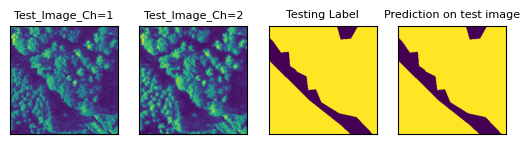

<Figure size 1200x800 with 0 Axes>

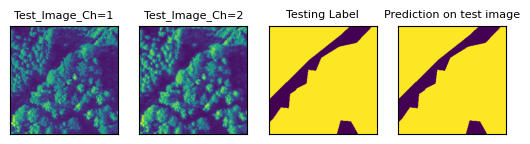

<Figure size 1200x800 with 0 Axes>

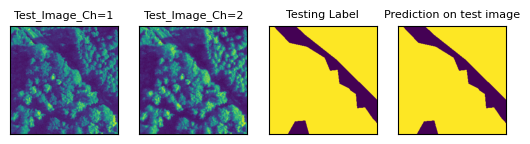

<Figure size 1200x800 with 0 Axes>

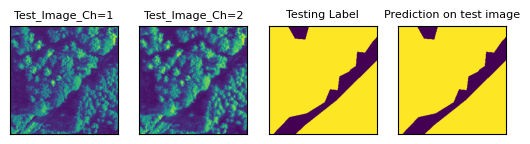

<Figure size 1200x800 with 0 Axes>

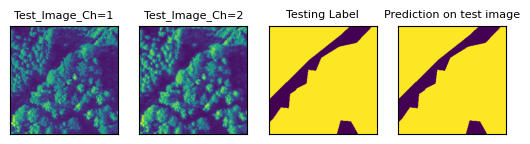

<Figure size 1200x800 with 0 Axes>

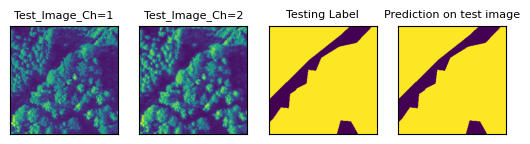

<Figure size 1200x800 with 0 Axes>

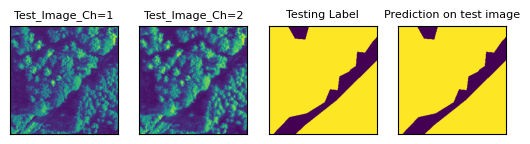

<Figure size 1200x800 with 0 Axes>

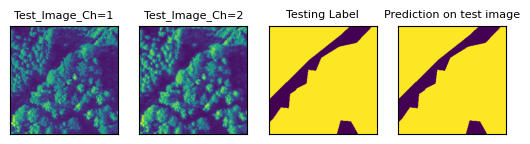

<Figure size 1200x800 with 0 Axes>

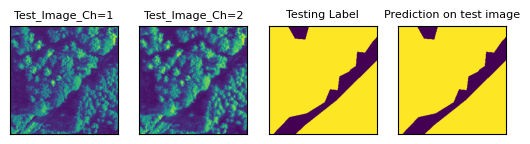

<Figure size 1200x800 with 0 Axes>

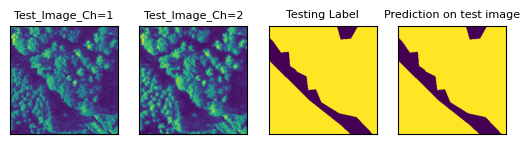

<Figure size 1200x800 with 0 Axes>

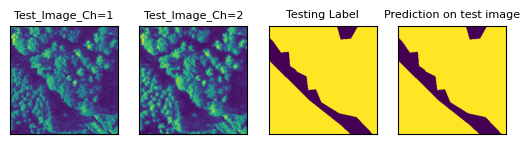

<Figure size 1200x800 with 0 Axes>

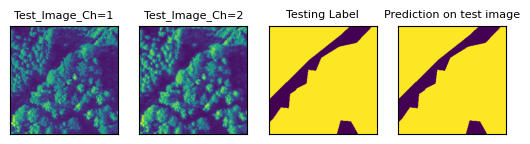

<Figure size 1200x800 with 0 Axes>

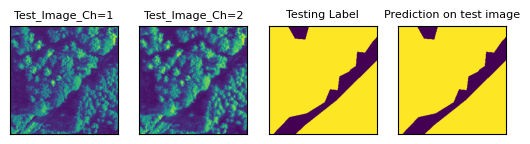

<Figure size 1200x800 with 0 Axes>

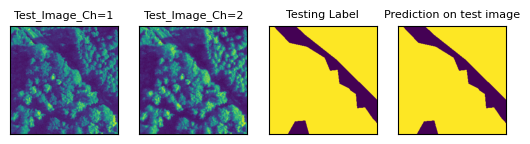

<Figure size 1200x800 with 0 Axes>

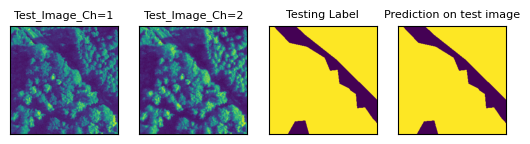

<Figure size 1200x800 with 0 Axes>

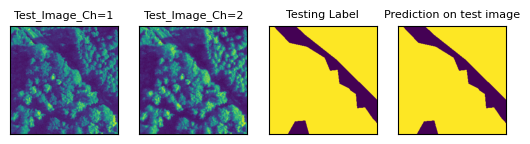

<Figure size 1200x800 with 0 Axes>

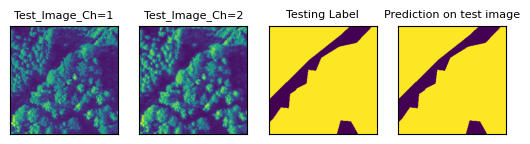

<Figure size 1200x800 with 0 Axes>

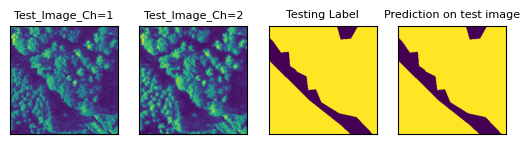

<Figure size 1200x800 with 0 Axes>

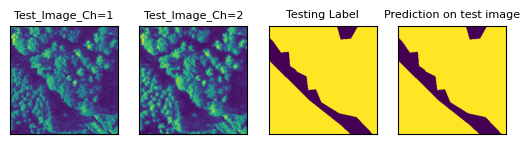

<Figure size 1200x800 with 0 Axes>

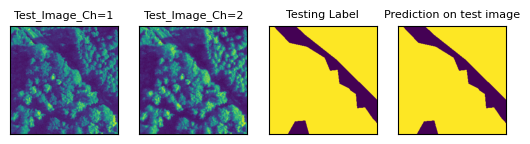

<Figure size 1200x800 with 0 Axes>

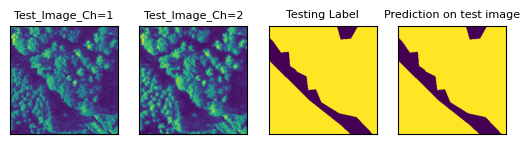

<Figure size 1200x800 with 0 Axes>

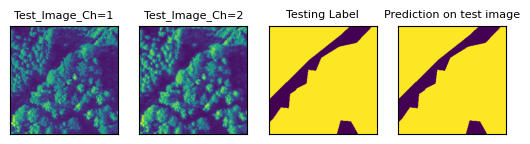

<Figure size 1200x800 with 0 Axes>

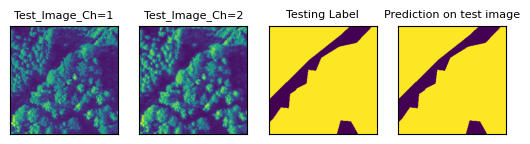

<Figure size 1200x800 with 0 Axes>

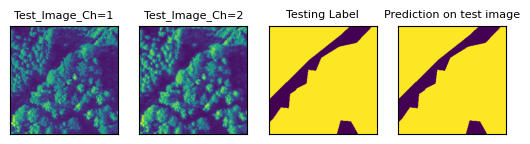

<Figure size 1200x800 with 0 Axes>

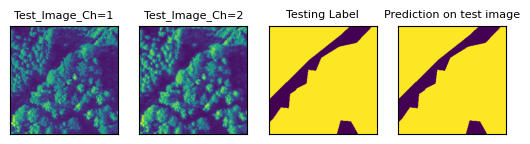

<Figure size 1200x800 with 0 Axes>

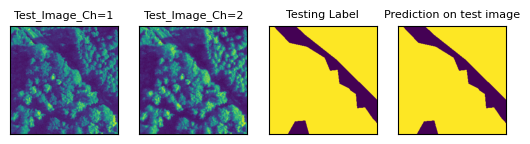

<Figure size 1200x800 with 0 Axes>

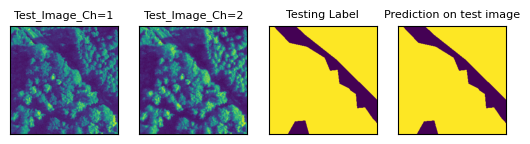

<Figure size 1200x800 with 0 Axes>

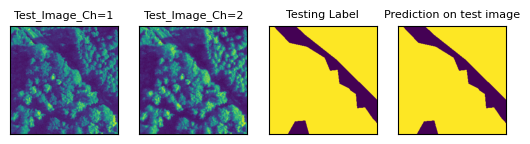

<Figure size 1200x800 with 0 Axes>

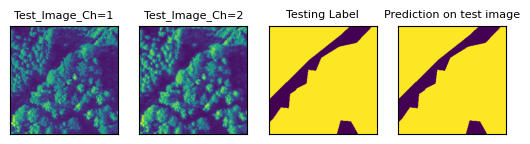

In [42]:
for img_num in range(test_image_batch.shape[0]-1):

    fig=plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    figure, axis = plt.subplots(1, 4)
    fig.tight_layout()

    axis[0].imshow(test_image_batch[img_num][:,:,0])
    axis[0].set_title('Test_Image_Ch=1', fontsize = 8)
    axis[0].axes.xaxis.set_visible(False)
    axis[0].axes.yaxis.set_visible(False)

    axis[1].imshow(test_image_batch[img_num][:,:,1])
    axis[1].set_title('Test_Image_Ch=2', fontsize = 8)
    axis[1].axes.xaxis.set_visible(False)
    axis[1].axes.yaxis.set_visible(False)

    axis[2].imshow(test_mask_batch_argmax[img_num])
    axis[2].set_title("Testing Label", fontsize = 8)
    axis[2].axes.xaxis.set_visible(False)
    axis[2].axes.yaxis.set_visible(False)

    axis[3].imshow(test_pred_batch_argmax[img_num])
    axis[3].set_title("Prediction on test image", fontsize = 8)
    axis[3].axes.xaxis.set_visible(False)
    axis[3].axes.yaxis.set_visible(False)

    plt.show()

# Задание №2. Создание и обучение модели семантической сегментации для классификации спутниковых снимков

In [43]:
from tensorflow.keras import Model, Input
from keras.layers import Conv2D, MaxPooling2D, concatenate, UpSampling2D, Dropout, Cropping2D, Softmax, Conv2DTranspose
from keras.preprocessing import image
from tensorflow.keras.utils import plot_model

In [63]:
def mini_u_net(image_shape, num_of_classes):

  input_image = Input(image_shape)

  # Encoder

  conv1_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_1')(input_image)
  conv1_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_2')(conv1_1)

  pool_1 = MaxPooling2D(name = 'pool_1')(conv1_2)

  conv2_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_1')(pool_1)
  conv2_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_2')(conv2_1)

  pool_2 = MaxPooling2D(name = 'pool_2')(conv2_2)

  conv3_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_1')(pool_2)
  conv3_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_2')(conv3_1)

  pool_3 = MaxPooling2D(name = 'pool_3')(conv3_2)

  conv4_1 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_1')(pool_3)
  conv4_2 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_2')(conv4_1)



  # Decoder

  upconv5_1 = UpSampling2D(name = 'upconv5_1')(conv4_2)
  upconv5_2 = Conv2D(filters = 128, kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv5_2')(upconv5_1)
  concat_5 = concatenate([upconv5_2, conv3_2], axis = 3, name = 'concat_5') # Split Connections

  conv5_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_1')(concat_5)
  conv5_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_2')(conv5_1)


  upconv6_1 = UpSampling2D(name = 'upconv6_1')(conv5_2)
  upconv6_2 = Conv2D(filters = 64, kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv6_2')(upconv6_1)
  concat_6 = concatenate([upconv6_2, conv2_2], axis = 3, name = 'concat_6') # Split Connections

  conv6_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_1')(concat_6)
  conv6_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_2')(conv6_1)

  upconv7_1 = UpSampling2D(name = 'upconv7_1')(conv6_2)
  upconv7_2 = Conv2D(filters = 32, kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv7_2')(upconv7_1)
  concat_7 = concatenate([upconv7_2, conv1_2], axis = 3, name = 'concat_7') # Split Connections

  conv7_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_1')(concat_7)
  conv7_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_2')(conv7_1)

  conv8 = Conv2D(filters = num_of_classes, kernel_size = (1, 1), activation = 'softmax', name = 'conv8')(conv7_2)

  model = Model(inputs = input_image, outputs = conv8, name = 'model')

  return model

In [64]:
unet_model = mini_u_net(image_shape = [256, 256, 3], num_of_classes = 6)

In [65]:
unet_model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1 (Conv2D)    │ (None, 256, 256,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2 (Conv2D)    │ (None, 256, 256,  │      9,248 │ conv1_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, 128, 128,  │          0 │ conv1_2[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1 (Conv2D)    │ (None, 128, 128,  │     18,496 │ pool_1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2 (Conv2D)    │ (None, 128, 128,  │     36,928 │ conv2_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 64, 64,    │          0 │ conv2_2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_1 (Conv2D)    │ (None, 64, 64,    │     73,856 │ pool_2[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_2 (Conv2D)    │ (None, 64, 64,    │    147,584 │ conv3_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 32, 32,    │          0 │ conv3_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4_1 (Conv2D)    │ (None, 32, 32,    │    295,168 │ pool_3[0][0]      │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4_2 (Conv2D)    │ (None, 32, 32,    │    590,080 │ conv4_1[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upconv5_1           │ (None, 64, 64,    │          0 │ conv4_2[0][0]     │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upconv5_2 (Conv2D)  │ (None, 64, 64,    │    131,200 │ upconv5_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_5            │ (None, 64, 64,    │          0 │ upconv5_2[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv3_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv5_1 (Conv2D)    │ (None, 64, 64,    │    295,040 │ concat_5[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv5_2 (Conv2D)    │ (None, 64, 64,    │    147,584 │ conv5_1[0][0]   

 Total params: 1,925,766 (7.35 MB)

 Trainable params: 1,925,766 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
unet_model.get_config()

{'name': 'model',
 'trainable': True,
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 256, 256, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer_2'},
   'registered_name': None,
   'name': 'input_layer_2',
   'inbound_nodes': []},
  {'module': 'keras.layers',
   'class_name': 'Conv2D',
   'config': {'name': 'conv1_1',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'filters': 32,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 'kera

In [67]:
def mini_u_net(image_shape, num_of_classes):

    input_image = Input(image_shape)

    # Encoder

    conv1_1 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_1')(input_image)
    dropout1_1 = Dropout(rate=0.2)(conv1_1)
    conv1_2 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_2')(dropout1_1)

    pool_1 = MaxPooling2D(pool_size=(2,2), name = 'pool_1')(conv1_2)

    conv2_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_1')(pool_1)
    dropout2_1 = Dropout(rate=0.2)(conv2_1)
    conv2_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_2')(dropout2_1)

    pool_2 = MaxPooling2D(pool_size=(2,2), name = 'pool_2')(conv2_2)

    conv3_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_1')(pool_2)
    dropout3_1 = Dropout(rate=0.2)(conv3_1)
    conv3_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_2')(dropout3_1)

    pool_3 = MaxPooling2D(pool_size=(2,2), name = 'pool_3')(conv3_2)

    conv4_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_1')(pool_3)
    dropout4_1 = Dropout(rate=0.2)(conv4_1)
    conv4_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_2')(dropout4_1)


    pool_4 = MaxPooling2D(pool_size=(2,2), name = 'pool_4')(conv4_2)


    conv5_1 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_1')(pool_4)
    dropout5_1 = Dropout(rate=0.2)(conv5_1)
    conv5_2 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_2')(dropout5_1)

    # Decoder

    upconv5_1 = Conv2DTranspose(filters = 128, kernel_size = (2, 2), strides=(2, 2), activation = 'linear', padding = 'same', name = 'upconv5_1')(conv5_2)

    concat_5 = concatenate([upconv5_1, conv4_2], axis = 3, name = 'concat_5') # Split Connections


    conv6_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_1')(concat_5)
    dropout6_1 = Dropout(rate=0.2)(conv6_1)
    conv6_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_2')(dropout6_1)
    upconv6_1 = Conv2DTranspose(filters = 64, kernel_size = (2, 2), strides=(2, 2), activation = 'linear', padding = 'same', name = 'upconv6_1')(conv6_2)

    concat_6 = concatenate([upconv6_1, conv3_2], axis = 3, name = 'concat_6') # Split Connections

    conv7_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_1')(concat_6)
    dropout7_1 = Dropout(rate=0.2)(conv7_1)
    conv7_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_2')(dropout7_1)
    upconv7_1 = Conv2DTranspose(filters = 32, strides=(2, 2), kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv7_1')(conv7_2)

    concat_7 = concatenate([upconv7_1, conv2_2], axis = 3, name = 'concat_7') # Split Connections

    conv8_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv8_1')(concat_7)
    dropout8_1 = Dropout(rate=0.2)(conv8_1)
    conv8_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv8_2')(dropout8_1)
    upconv8_1 = Conv2DTranspose(filters = 16, strides=(2, 2), kernel_size = (2, 2), activation = 'linear', padding = 'same', name = 'upconv8_1')(conv8_2)

    concat_8 = concatenate([upconv8_1, conv1_2], axis = 3, name = 'concat_8') # Split Connections


    conv9_1 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv9_1')(concat_8)
    dropout9_1 = Dropout(rate=0.2)(conv9_1)
    conv9_2 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv9_2')(dropout9_1)

    conv10 = Conv2D(filters = num_of_classes, kernel_size = (1, 1), activation = 'softmax', name = 'conv10')(conv9_2)

    model = Model(inputs = input_image, outputs = conv10, name = 'model')

    return model

In [68]:
model_2 = mini_u_net(image_shape = [256, 256, 3], num_of_classes = 5)

In [70]:
model_2.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1 (Conv2D)    │ (None, 256, 256,  │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256, 256,  │          0 │ conv1_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2 (Conv2D)    │ (None, 256, 256,  │      2,320 │ dropout_9[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, 128, 128,  │          0 │ conv1_2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1 (Conv2D)    │ (None, 128, 128,  │      4,640 │ pool_1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128, 128,  │          0 │ conv2_1[0][0]     │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2 (Conv2D)    │ (None, 128, 128,  │      9,248 │ dropout_10[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 64, 64,    │          0 │ conv2_2[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_1 (Conv2D)    │ (None, 64, 64,    │     18,496 │ pool_2[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64, 64,    │          0 │ conv3_1[0][0]     │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_2 (Conv2D)    │ (None, 64, 64,    │     36,928 │ dropout_11[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 32, 32,    │          0 │ conv3_2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4_1 (Conv2D)    │ (None, 32, 32,    │     73,856 │ pool_3[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32, 32,    │          0 │ conv4_1[0][0]     │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4_2 (Conv2D)    │ (None, 32, 32,    │    147,584 │ dropout_12[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 16, 16,    │          0 │ conv4_2[0][0]   

 Total params: 1,941,173 (7.40 MB)

 Trainable params: 1,941,173 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model_2.get_config()

{'name': 'model',
 'trainable': True,
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 256, 256, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer_3'},
   'registered_name': None,
   'name': 'input_layer_3',
   'inbound_nodes': []},
  {'module': 'keras.layers',
   'class_name': 'Conv2D',
   'config': {'name': 'conv1_1',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'filters': 16,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 'kera

In [52]:
%pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [72]:
plot_model(
model_2, to_file='model.png', show_shapes=False, show_dtype=False,
show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [73]:
from keras.models import Model
from keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Conv2DTranspose, concatenate
from keras.optimizers import Adam

In [74]:
model_2.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [75]:
history2=model_2.fit(
          train_img_gen,
          steps_per_epoch=steps_per_epoch,
          epochs=5,
          verbose=1,
          validation_data=None)

Epoch 1/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 2366s 2s/step - accuracy: 0.8887 - loss: 0.3465
Epoch 2/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 2371s 2s/step - accuracy: 0.9986 - loss: 0.0034
Epoch 3/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 2320s 2s/step - accuracy: 0.9996 - loss: 9.8008e-04
Epoch 4/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 2323s 2s/step - accuracy: 0.9160 - loss: 0.3657
Epoch 5/5
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 2314s 2s/step - accuracy: 0.8516 - loss: 0.3811


In [76]:
model_2.save("model_2.keras")

## 2.2. Обучите созданную модель для решения задачи семантической сегментации. В качестве функции потерь используйте ту, которая лучше всего показала себя в задании №1

### 2.2.1. Используя обученную модель, обработайте снимки по технологии, рассмотренной на практическом занятии (делим снимок на части, затем каждую часть обрабатываем нейросетью, а после соединяем все части для получения полноразмерной маски исходного снимка)

In [77]:
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import MeanIoU

# Загрузка модели model_resnet и model_2
model_resnet = load_model('model_resnet.keras', custom_objects={'jacard_coef': jacard_coef})
model_2 = load_model('model_2.keras')  

# Получение тестового изображения и соответствующей ему маски
test_image_batch, test_mask_batch = train_img_gen.__next__()

# Преобразование маски из категориального формата в формат меток классов
test_mask_batch_argmax = np.argmax(test_mask_batch, axis=3)

# Выполнение предсказания на тестовом изображении с обеими моделями
test_pred_batch_resnet = model_resnet.predict(test_image_batch)
test_pred_batch_model_2 = model_2.predict(test_image_batch)

# Преобразование предсказания из вероятностного формата в формат меток классов
test_pred_batch_resnet_argmax = np.argmax(test_pred_batch_resnet, axis=3)
test_pred_batch_model_2_argmax = np.argmax(test_pred_batch_model_2, axis=3)

# Количество классов
n_classes = 5

# Инициализация объекта для вычисления среднего IoU для обеих моделей
IOU_keras_resnet = MeanIoU(num_classes=n_classes)
IOU_keras_model_2 = MeanIoU(num_classes=n_classes)

# Обновление состояния объекта среднего IoU на основе предсказания и истинной маски для обеих моделей
IOU_keras_resnet.update_state(test_pred_batch_resnet_argmax, test_mask_batch_argmax)
IOU_keras_model_2.update_state(test_pred_batch_model_2_argmax, test_mask_batch_argmax)

# Вывод среднего IoU для обеих моделей
print("Mean IoU (ResNet) =", IOU_keras_resnet.result().numpy())
print("Mean IoU (model_2) =", IOU_keras_model_2.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
Mean IoU (ResNet) = 0.99967
Mean IoU (model_2) = 0.42580414


### 2.2.2. Отобразите предсказанную маску для каждого из трех снимков, загруженных ранее, в следующем формате: (исходный снимок, эталонная маска, предсказанная маска по модели, обученной в этом задании, предсказанная маска по модели, обученной в первом задании.

<Figure size 1200x800 with 0 Axes>

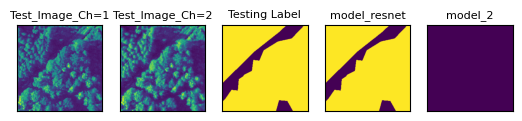

<Figure size 1200x800 with 0 Axes>

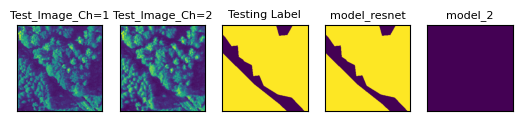

<Figure size 1200x800 with 0 Axes>

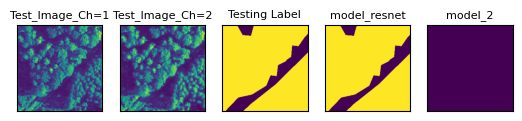

<Figure size 1200x800 with 0 Axes>

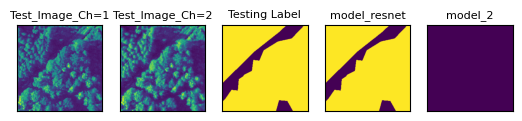

<Figure size 1200x800 with 0 Axes>

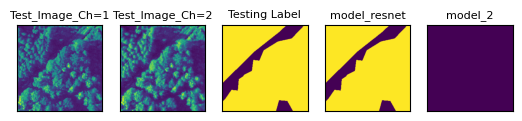

<Figure size 1200x800 with 0 Axes>

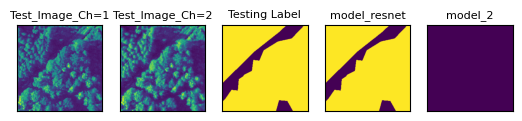

<Figure size 1200x800 with 0 Axes>

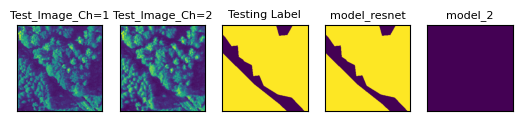

<Figure size 1200x800 with 0 Axes>

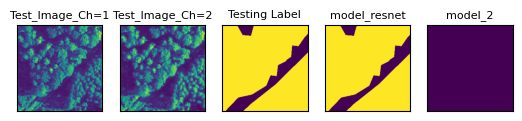

<Figure size 1200x800 with 0 Axes>

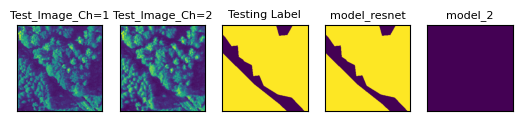

<Figure size 1200x800 with 0 Axes>

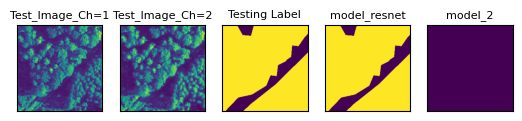

<Figure size 1200x800 with 0 Axes>

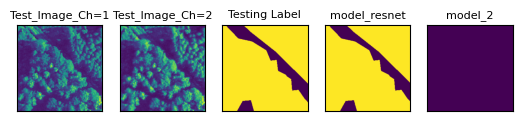

<Figure size 1200x800 with 0 Axes>

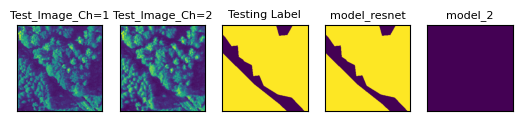

<Figure size 1200x800 with 0 Axes>

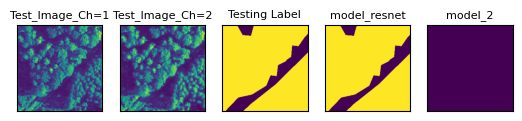

<Figure size 1200x800 with 0 Axes>

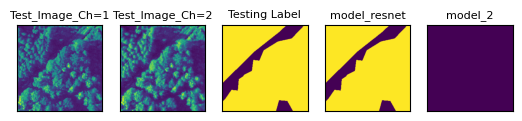

<Figure size 1200x800 with 0 Axes>

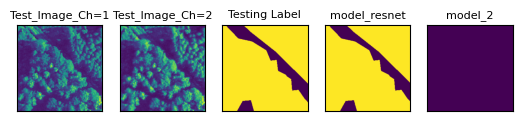

<Figure size 1200x800 with 0 Axes>

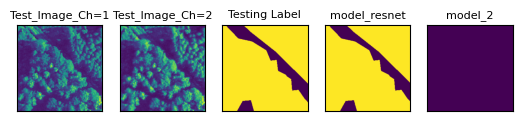

<Figure size 1200x800 with 0 Axes>

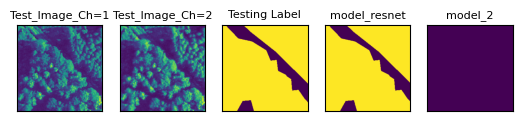

<Figure size 1200x800 with 0 Axes>

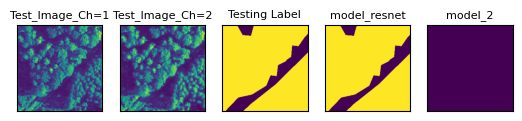

<Figure size 1200x800 with 0 Axes>

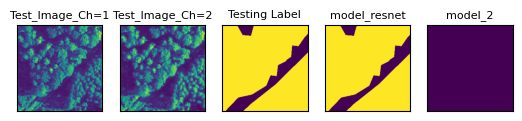

<Figure size 1200x800 with 0 Axes>

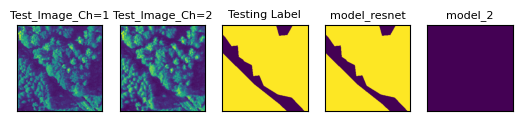

<Figure size 1200x800 with 0 Axes>

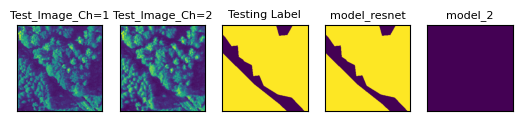

<Figure size 1200x800 with 0 Axes>

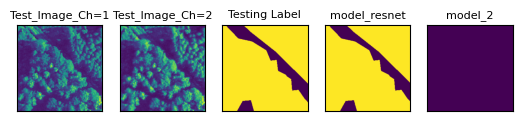

<Figure size 1200x800 with 0 Axes>

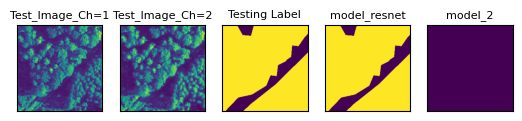

<Figure size 1200x800 with 0 Axes>

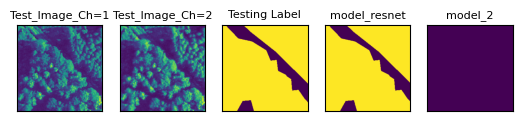

<Figure size 1200x800 with 0 Axes>

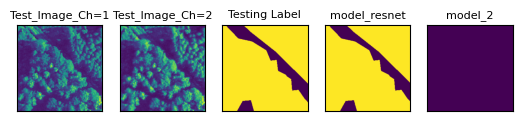

<Figure size 1200x800 with 0 Axes>

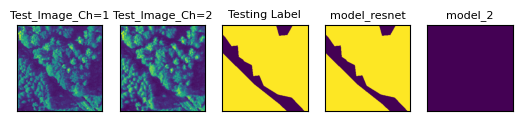

<Figure size 1200x800 with 0 Axes>

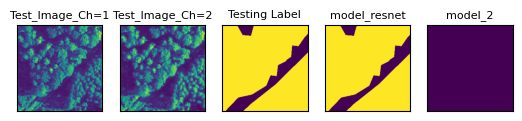

<Figure size 1200x800 with 0 Axes>

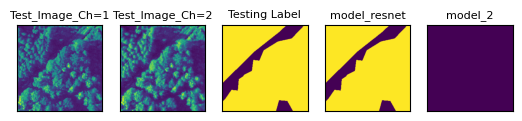

<Figure size 1200x800 with 0 Axes>

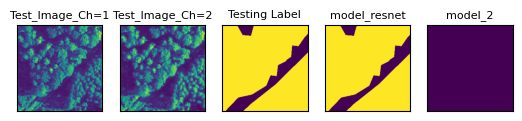

<Figure size 1200x800 with 0 Axes>

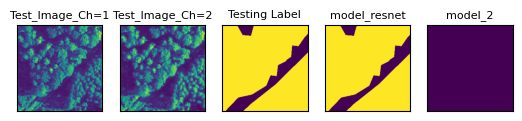

In [78]:
for img_num in range(test_image_batch.shape[0]):

    fig = plt.figure(figsize=(12, 8), facecolor='w', edgecolor='k')
    figure, axis = plt.subplots(1, 5)
    fig.tight_layout()

    # Отображение изображений
    axis[0].imshow(test_image_batch[img_num][:, :, 0])
    axis[0].set_title('Test_Image_Ch=1', fontsize=8)
    axis[0].axes.xaxis.set_visible(False)
    axis[0].axes.yaxis.set_visible(False)

    axis[1].imshow(test_image_batch[img_num][:, :, 1])
    axis[1].set_title('Test_Image_Ch=2', fontsize=8)
    axis[1].axes.xaxis.set_visible(False)
    axis[1].axes.yaxis.set_visible(False)

    axis[2].imshow(test_mask_batch_argmax[img_num])
    axis[2].set_title("Testing Label", fontsize=8)
    axis[2].axes.xaxis.set_visible(False)
    axis[2].axes.yaxis.set_visible(False)

    axis[3].imshow(test_pred_batch_resnet_argmax[img_num])
    axis[3].set_title("model_resnet", fontsize=8)
    axis[3].axes.xaxis.set_visible(False)
    axis[3].axes.yaxis.set_visible(False)

    axis[4].imshow(test_pred_batch_model_2_argmax[img_num])
    axis[4].set_title("model_2", fontsize=8)
    axis[4].axes.xaxis.set_visible(False)
    axis[4].axes.yaxis.set_visible(False)

    plt.show()

# Задание №3. Реализация готового решения для полноразмерной семантической сегментации спутникового снимка

## Реализуйте готовый алгоритм, который принимает на вход полноразмерное изображение и маску (опционально). После чего на его основе формирует полноразмерную маску, предсказанную наиболее удачной моделью нейронной сети, обученной ранее в Задании №1 или Задании №2.

In [79]:
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

from patchify import patchify, unpatchify

In [80]:
model_resnet = load_model('model_resnet.keras', custom_objects={'jacard_coef': jacard_coef})

In [81]:
def pred_mask(img, mask=None):
  #Без предотвращения краевого эффекта
  # Определение размеров изображения, которые кратны размеру патча
  SIZE_X = (img.shape[1]//patch_size)*patch_size  # Ширина изображения
  SIZE_Y = (img.shape[0]//patch_size)*patch_size  # Высота изображения

  # Преобразование массива numpy в объект изображения PIL
  large_img = Image.fromarray(img)

  # Обрезка изображения до размеров, кратных размеру патча
  large_img = large_img.crop((0 ,0, SIZE_X, SIZE_Y))

  # Преобразование объекта изображения PIL обратно в массив numpy
  large_img = np.array(large_img)

  # Разбиение изображения на патчи с использованием функции patchify
  patches_img = patchify(large_img, (patch_size, patch_size, 3), step=patch_size)

  # Удаление лишней оси из массива патчей
  patches_img = patches_img[:,:,0,:,:,:]

    # Инициализация списка для хранения предсказаний на каждом патче
  patched_prediction = []

  # Цикл по каждому патчу изображения
  for i in range(patches_img.shape[0]):
      for j in range(patches_img.shape[1]):

          # Выбор одного патча изображения
          single_patch_img = patches_img[i,j,:,:,:]

          # Нормализация патча изображения с использованием объекта scaler
          single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)

          # Добавление дополнительной оси в начало массива для соответствия формату входных данных модели
          single_patch_img = np.expand_dims(single_patch_img, axis=0)

          # Выполнение предсказания модели на патче изображения
          pred = model_resnet.predict(single_patch_img)

          # Выбор класса с наибольшей вероятностью в каждом пикселе
          pred = np.argmax(pred, axis=3)

          # Удаление лишней оси из массива предсказания
          pred = pred[0, :,:]

          # Добавление предсказания в список
          patched_prediction.append(pred)

  # Преобразование списка предсказаний в массив numpy
  patched_prediction = np.array(patched_prediction)

  # Изменение формы массива предсказаний, чтобы он соответствовал форме массива патчей изображения
  patched_prediction = np.reshape(patched_prediction, [patches_img.shape[0], patches_img.shape[1],
                                              patches_img.shape[2], patches_img.shape[3]])

  # Объединение патчей предсказаний в одно большое изображение
  unpatched_prediction = unpatchify(patched_prediction, (large_img.shape[0], large_img.shape[1]))

  # Создаем фигуру для отображения
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

  # Отображаем исходное изображение
  ax1.imshow(img)
  ax1.set_title('Исходное изображение')
  ax1.axis('off')

  # Отображаем исходную маску
  ax2.imshow(mask)
  ax2.set_title('Исходная маска')
  ax2.axis('off')

  # Отображаем маску
  ax3.imshow(unpatched_prediction)
  ax3.set_title('Предсказанная маска')
  ax3.axis('off')

  plt.show()
  # Сохраняем результат
  output_path = "comparison_result.png"
  plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
  plt.close()

  return output_path

In [82]:
img = tiff.imread('images/N-33-96-D-d-1-1.tif')
mask = tiff.imread('masks/N-33-96-D-d-1-1.tif')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10

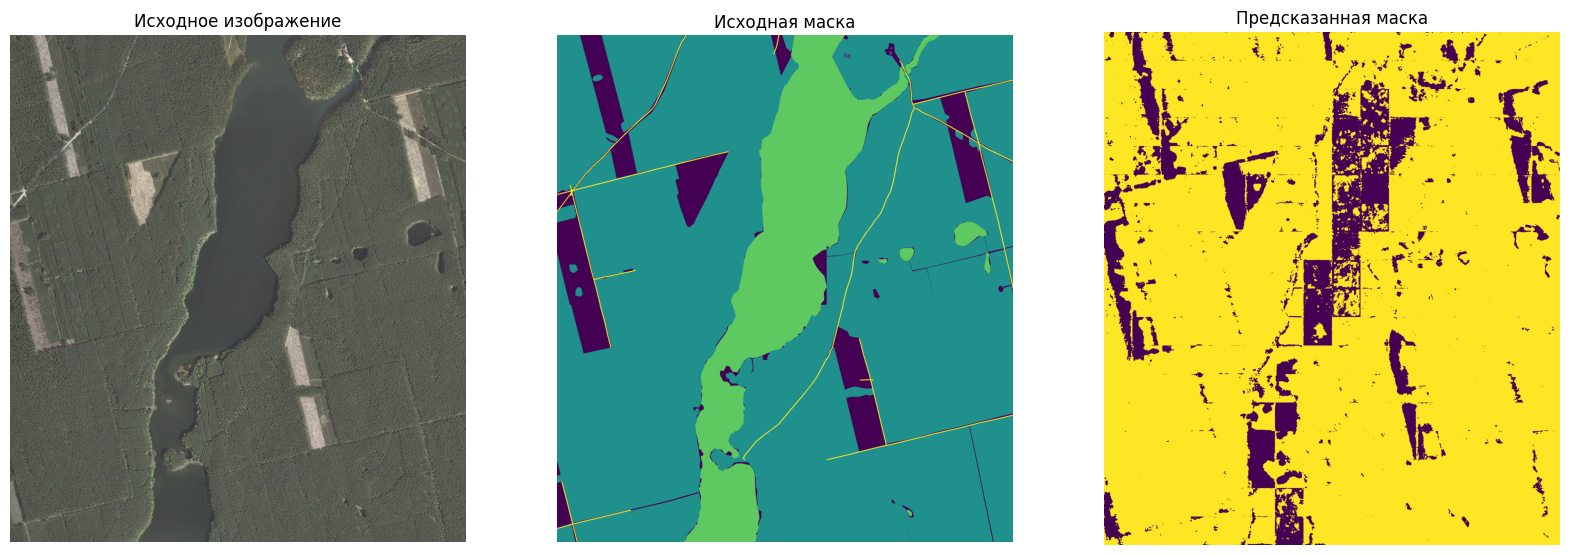

'comparison_result.png'

In [83]:
pred_mask(img, mask)

In [84]:
%pip install -q gradio

Note: you may need to restart the kernel to use updated packages.


In [85]:
import gradio as gr
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from patchify import patchify, unpatchify

def pred_mask_grad(img):
    #Без предотвращения краевого эффекта
    # Определение размеров изображения, которые кратны размеру патча
    SIZE_X = (img.shape[1]//patch_size)*patch_size  # Ширина изображения
    SIZE_Y = (img.shape[0]//patch_size)*patch_size  # Высота изображения

    # Преобразование массива numpy в объект изображения PIL
    large_img = Image.fromarray(img)

    # Обрезка изображения до размеров, кратных размеру патча
    large_img = large_img.crop((0 ,0, SIZE_X, SIZE_Y))

    # Преобразование объекта изображения PIL обратно в массив numpy
    large_img = np.array(large_img)

    # Разбиение изображения на патчи с использованием функции patchify
    patches_img = patchify(large_img, (patch_size, patch_size, 3), step=patch_size)

    # Удаление лишней оси из массива патчей
    patches_img = patches_img[:,:,0,:,:,:]

      # Инициализация списка для хранения предсказаний на каждом патче
    patched_prediction = []

    # Цикл по каждому патчу изображения
    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):

            # Выбор одного патча изображения
            single_patch_img = patches_img[i,j,:,:,:]

            # Нормализация патча изображения с использованием объекта scaler
            single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)

            # Добавление дополнительной оси в начало массива для соответствия формату входных данных модели
            single_patch_img = np.expand_dims(single_patch_img, axis=0)

            # Выполнение предсказания модели на патче изображения
            pred = model_resnet.predict(single_patch_img)

            # Выбор класса с наибольшей вероятностью в каждом пикселе
            pred = np.argmax(pred, axis=3)

            # Удаление лишней оси из массива предсказания
            pred = pred[0, :,:]

            # Добавление предсказания в список
            patched_prediction.append(pred)

    # Преобразование списка предсказаний в массив numpy
    patched_prediction = np.array(patched_prediction)

    # Изменение формы массива предсказаний, чтобы он соответствовал форме массива патчей изображения
    patched_prediction = np.reshape(patched_prediction, [patches_img.shape[0], patches_img.shape[1],
                                                patches_img.shape[2], patches_img.shape[3]])

    # Объединение патчей предсказаний в одно большое изображение
    unpatched_prediction = unpatchify(patched_prediction, (large_img.shape[0], large_img.shape[1]))

    # Сохраняем маску
    mask_path = "predicted_mask.png"
    plt.imsave(mask_path, unpatched_prediction)

    return mask_path

e:\projects\neural_networks-main\PR_7\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [86]:
interface = gr.Interface(
    fn=pred_mask_grad,
    inputs=gr.Image(label="Исходное изображение"),
    outputs=gr.Image(label="Предсказанная маска", type="filepath"),
    examples=[["images/N-33-96-D-d-1-1.tif"]],
    title="Сегментация изображений",
    description="Загрузите изображение для получения маски сегментации."
)
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
